In [25]:
# cost_surface_model.ipynb

# --- 0. Setup and Imports ---
import geopandas as gpd
import pandas as pd
import numpy as np
import os
import sys # Needed to add src directory to path

# --- Define Base Directory ---
# Assumes your notebook is IN the PA2-Modelling_Wildlife_Corridors directory
# If it's somewhere else, adjust this path accordingly.
BASE_DIR = os.path.abspath('../..') # Gets the current directory of the notebook

In [26]:
# --- Define Subdirectories ---
DATA_DIR = os.path.join(BASE_DIR, "data")
RESULTS_DIR = os.path.join(BASE_DIR, "Results")

In [27]:
# Import your custom GIS functions
import gis_utils as gu

In [28]:
## --- Define Input File Paths (Relative to DATA_DIR) ---
# BOUNDARIES_PATH = os.path.join(DATA_DIR, "swissBOUNDARIES3D_1_5_LV95_LN02.gpkg")
# SWISSTLM_PATH = os.path.join(DATA_DIR, "SWISSTLM3D_2025.gpkg")
# CORINE_PATH = os.path.join(DATA_DIR, "U2018_CLC2018_V2020_20u1.gpkg")
# CORINE_LEGEND_PATH = os.path.join(DATA_DIR, "Info", "Legend", "Vector", "CLC_legend.csv")
# COST_CSV_PATH = os.path.join(DATA_DIR, "resistance_costs.csv")

In [29]:
BOUNDARIES_PATH = os.path.join("C:\\ZHAW\\5.Semester\\PA2\\data", "swissBOUNDARIES3D_1_5_LV95_LN02.gpkg")
SWISSTLM_PATH = os.path.join("C:\\ZHAW\\5.Semester\\PA2\\data", "SWISSTLM3D_2025.gpkg")
CORINE_PATH = os.path.join("C:\\ZHAW\\5.Semester\\PA2\\data\\Results", "U2018_CLC2018_V2020_20u1.gpkg")
CORINE_LEGEND_PATH = os.path.join("C:\\ZHAW\\5.Semester\\PA2\\data\\Results\\Info\\Legend\\Vector", "CLC_legend.csv")
COST_CSV_PATH = os.path.join("C:\\ZHAW\\5.Semester\\PA2\\PA2-Modelling_Wildlife_Corridors\\data", "resistance_costs.csv")

In [30]:
# --- Define Output File Paths (Relative to RESULTS_DIR) ---
LANDCOVER_SWISSTLM_RASTER = os.path.join(RESULTS_DIR, "temp_swisstlm_lc_resist.tif")
LANDCOVER_CORINE_RASTER = os.path.join(RESULTS_DIR, "temp_corine_lc_resist.tif")
HARMONIZED_TYPE_RASTER = os.path.join(RESULTS_DIR, "harmonized_landcover_type.tif")
LANDCOVER_RESISTANCE_RASTER = os.path.join(RESULTS_DIR, "base_landcover_resistance.tif")
WATER_BARRIER_RASTER = os.path.join(RESULTS_DIR, "temp_water_barrier.tif")
ROAD_BARRIER_RASTER = os.path.join(RESULTS_DIR, "temp_road_barrier.tif")
FINAL_RASTER = os.path.join(RESULTS_DIR, "final_resistance_surface.tif")

In [31]:
# --- Define Workflow Settings ---
TARGET_CANTON = "Schaffhausen"
BUFFER_M = 10000 # Buffer around canton for context
TARGET_RESOLUTION_M = 10.0
MIN_VALID_COST = 0 # Lowest cost (e.g., forest) to replace NoData during combination

In [32]:
# --- 1. Define Area of Interest (AOI) ---
# Filter for Schaffhausen, buffered, and clipped to Switzerland
sh, sh_bbox = gu.filter_canton(TARGET_CANTON, buffer_m=BUFFER_M)
target_crs = sh.crs # Get the CRS from the AOI

Loading canton boundary for Schaffhausen...
Loading national boundary (Switzerland)...
Applying 10000m buffer...
Clipping buffered area to Swiss national boundary...
Final AOI clipped to Swiss territory. BBox computed.


In [33]:
# --- 2. Load and Prepare Vector Layers ---

# Load SwissTLM3D Landcover (BODENBEDECKUNG)
landcover_sh = gu.load_and_clip_vector(SWISSTLM_PATH, "tlm_bb_bodenbedeckung", sh, sh_bbox)

Loading and clipping vector: tlm_bb_bodenbedeckung from C:\ZHAW\5.Semester\PA2\data\SWISSTLM3D_2025.gpkg
Clipping tlm_bb_bodenbedeckung to AOI geometry...
Loaded and clipped 9806 features from tlm_bb_bodenbedeckung.


In [34]:
# Load Corine Landcover & Merge Legend
try:
    landcover_clc_raw = gpd.read_file(CORINE_PATH, layer="U2018_CLC2018_V2020_20u1", engine="pyogrio") # Load full layer first
except Exception as e:
    print(f"Trying default engine for Corine. Error: {e}")
    landcover_clc_raw = gpd.read_file(CORINE_PATH, layer="U2018_CLC2018_V2020_20u1")

clc_legend = pd.read_csv(CORINE_LEGEND_PATH, sep=';')
landcover_clc_raw['Code_18'] = landcover_clc_raw['Code_18'].astype(int)
landcover_clc_with_labels = landcover_clc_raw.merge(
    clc_legend[['CLC_CODE', 'LABEL3']], left_on='Code_18', right_on='CLC_CODE', how='left'
)
# Clip Corine to AOI (Make sure CRS matches first)
if landcover_clc_with_labels.crs != target_crs:
     landcover_clc_with_labels = landcover_clc_with_labels.to_crs(target_crs)
landcover_sh_clc_clipped = gpd.clip(landcover_clc_with_labels, sh)

In [35]:
# Load Water Layers
f_water_sh = gu.load_and_clip_vector(SWISSTLM_PATH, "tlm_gewaesser_fliessgewaesser", sh, sh_bbox)
s_water_sh = gu.load_and_clip_vector(SWISSTLM_PATH, "tlm_gewaesser_stehendes_gewaesser", sh, sh_bbox)
# Combine Water
water_sh_combined = gpd.pd.concat([f_water_sh, s_water_sh], ignore_index=True)

# Load Roads
roads_sh = gu.load_and_clip_vector(SWISSTLM_PATH, "tlm_strassen_strasse", sh, sh_bbox)

Loading and clipping vector: tlm_gewaesser_fliessgewaesser from C:\ZHAW\5.Semester\PA2\data\SWISSTLM3D_2025.gpkg
Clipping tlm_gewaesser_fliessgewaesser to AOI geometry...
Loaded and clipped 7631 features from tlm_gewaesser_fliessgewaesser.
Loading and clipping vector: tlm_gewaesser_stehendes_gewaesser from C:\ZHAW\5.Semester\PA2\data\SWISSTLM3D_2025.gpkg
Clipping tlm_gewaesser_stehendes_gewaesser to AOI geometry...
Loaded and clipped 1672 features from tlm_gewaesser_stehendes_gewaesser.
Loading and clipping vector: tlm_strassen_strasse from C:\ZHAW\5.Semester\PA2\data\SWISSTLM3D_2025.gpkg
Clipping tlm_strassen_strasse to AOI geometry...
Loaded and clipped 85271 features from tlm_strassen_strasse.


In [36]:
# --- Define Unified Landcover Codes ---
# Create a unique integer ID for each meaningful landcover type
UNIFIED_LC_CODES = {
    'Forest': 1,
    'Scrub/Shrubland': 2, # Gebueschwald, Gehoelzflaeche
    'Open Forest/Edge': 3, # Wald offen
    'Agriculture Complex': 4, # Complex cultivation, Land principally occupied...
    'Arable Land': 5, # Non-irrigated arable land
    'Pasture/Grassland': 6, # Pastures
    'Orchards/Vineyards': 7, # Fruit trees, Vineyards
    'Wetland': 8, # Feuchtgebiet
    'Rocky/Bare': 9, # Fels, Felsbloecke, Lockergestein
    'Urban Fabric': 10, # Continuous/Discontinuous urban
    'Industrial/Commercial': 11,
    'Infrastructure': 12, # Road and rail networks (polygon)
    'Extraction/Leisure': 13, # Mineral extraction, Sport facilities
    # Water types omitted as requested previously
}
# Define a code for NoData/Background
UNIFIED_NODATA_CODE = 0 # Use 0 instead of -9999 for type codes if desired

# --- 2. Create Mappings from Original Data to Unified Codes ---
swisstlm_to_unified_map = {
    'Wald': UNIFIED_LC_CODES['Forest'],
    'Gebueschwald': UNIFIED_LC_CODES['Scrub/Shrubland'],
    'Gehoelzflaeche': UNIFIED_LC_CODES['Scrub/Shrubland'],
    'Wald offen': UNIFIED_LC_CODES['Open Forest/Edge'],
    'Feuchtgebiet': UNIFIED_LC_CODES['Wetland'],
    'Fels': UNIFIED_LC_CODES['Rocky/Bare'],
    'Felsbloecke locker': UNIFIED_LC_CODES['Rocky/Bare'],
    'Lockergestein': UNIFIED_LC_CODES['Rocky/Bare'],
    'Lockergestein locker': UNIFIED_LC_CODES['Rocky/Bare'],
    # Water types omitted
}

corine_to_unified_map = {
    'Broad-leaved forest': UNIFIED_LC_CODES['Forest'],
    'Coniferous forest': UNIFIED_LC_CODES['Forest'],
    'Mixed forest': UNIFIED_LC_CODES['Forest'],
    'Land principally occupied by agriculture, with significant areas of natural vegetation': UNIFIED_LC_CODES['Agriculture Complex'],
    'Complex cultivation patterns': UNIFIED_LC_CODES['Agriculture Complex'],
    'Fruit trees and berry plantations': UNIFIED_LC_CODES['Orchards/Vineyards'],
    'Pastures': UNIFIED_LC_CODES['Pasture/Grassland'],
    'Non-irrigated arable land': UNIFIED_LC_CODES['Arable Land'],
    'Vineyards': UNIFIED_LC_CODES['Orchards/Vineyards'],
    'Sport and leisure facilities': UNIFIED_LC_CODES['Extraction/Leisure'],
    'Mineral extraction sites': UNIFIED_LC_CODES['Extraction/Leisure'],
    'Road and rail networks and associated land': UNIFIED_LC_CODES['Infrastructure'],
    'Discontinuous urban fabric': UNIFIED_LC_CODES['Urban Fabric'],
    'Continuous urban fabric': UNIFIED_LC_CODES['Urban Fabric'],
    'Industrial or commercial units': UNIFIED_LC_CODES['Industrial/Commercial'],
     # Water types omitted
}

# --- 3. Define Resistance Costs for Unified Codes ---
# Single dictionary mapping the new codes to resistance values
unified_code_to_resistance_map = {
    UNIFIED_LC_CODES['Forest']: 5,
    UNIFIED_LC_CODES['Scrub/Shrubland']: 12, # Average of 10 & 15
    UNIFIED_LC_CODES['Open Forest/Edge']: 8,
    UNIFIED_LC_CODES['Agriculture Complex']: 27, # Average of 25 & 30
    UNIFIED_LC_CODES['Arable Land']: 50,
    UNIFIED_LC_CODES['Pasture/Grassland']: 40,
    UNIFIED_LC_CODES['Orchards/Vineyards']: 28, # Average of 20 & 35
    UNIFIED_LC_CODES['Wetland']: 45,
    UNIFIED_LC_CODES['Rocky/Bare']: 85, # Average of 100, 90, 80, 70
    UNIFIED_LC_CODES['Urban Fabric']: 225, # Average of 200 & 250
    UNIFIED_LC_CODES['Industrial/Commercial']: 220,
    UNIFIED_LC_CODES['Infrastructure']: 150,
    UNIFIED_LC_CODES['Extraction/Leisure']: 88, # Average of 75 & 100
    # Add costs for water/road barriers later using MAX logic
}
# Define a default resistance cost for any unmapped type codes
DEFAULT_RESISTANCE_COST = 255 # High cost for unexpected types

In [37]:
# Exclude Water Bodies from Landcover Layers
landcover_sh = landcover_sh[~landcover_sh['objektart'].isin(['Fliessgewaesser', 'Stehende Gewaesser'])].copy()
landcover_sh_clc_clipped = landcover_sh_clc_clipped[~landcover_sh_clc_clipped['LABEL3'].isin(['Water bodies', 'Water courses'])].copy()

In [38]:
# Apply UNIFIED TYPE CODES to Vector Layers
print("Applying unified type codes...")
landcover_sh['type_code'] = landcover_sh['objektart'].map(swisstlm_to_unified_map).fillna(gu.UNIFIED_NODATA_CODE)
landcover_sh_clc_clipped['type_code'] = landcover_sh_clc_clipped['LABEL3'].map(corine_to_unified_map).fillna(gu.UNIFIED_NODATA_CODE)

Applying unified type codes...


In [39]:
# --- 3. Load Resistance Costs from CSV ---
cost_maps = gu.load_resistance_costs(COST_CSV_PATH)

Loading resistance costs from C:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\data\resistance_costs.csv...
Loaded costs for types: ['swisstlm', 'corine', 'water', 'roads']


In [40]:
# --- 4. Apply Costs to Vector Layers ---
print("Applying costs to vector layers...")
# # Landcover - SwissTLM3D
# landcover_sh['resistance_cost'] = landcover_sh['objektart'].map(cost_maps.get('swisstlm', {})).fillna(gu.DEFAULT_NODATA)
# # Landcover - Corine
# landcover_sh_clc_clipped['resistance_cost'] = landcover_sh_clc_clipped['LABEL3'].map(cost_maps.get('corine', {})).fillna(gu.DEFAULT_NODATA)
# Water
water_sh_combined['resistance_cost'] = water_sh_combined['objektart'].map(cost_maps.get('water', {})).fillna(gu.DEFAULT_NODATA)
# Roads
roads_sh['resistance_cost'] = roads_sh['objektart'].map(cost_maps.get('roads', {})).fillna(gu.DEFAULT_NODATA)


Applying costs to vector layers...


In [41]:
# --- 5. Define Master Grid ---
# Define grid based on the full extent of all prepared layers
master_meta = gu.define_master_grid_meta(
    [landcover_sh.geometry, landcover_sh_clc_clipped.geometry, water_sh_combined.geometry, roads_sh.geometry],
    TARGET_RESOLUTION_M, target_crs
)

Defining master grid metadata...
Master grid: 4662x3849 pixels at 10.0m resolution.


In [42]:
# --- 6. Rasterize Layers ---
# Rasterize Landcover Layers BY TYPE CODE
print("Rasterizing landcover layers by type code...")
gu.rasterize_landcover_types(landcover_sh, master_meta, 'type_code', LANDCOVER_SWISSTLM_RASTER)
gu.rasterize_landcover_types(landcover_sh_clc_clipped, master_meta, 'type_code', LANDCOVER_CORINE_RASTER)

Rasterizing landcover layers by type code...
Rasterizing landcover types to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\temp_swisstlm_lc_resist.tif...
Burning 9037 features with type codes...
Saved raster to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\temp_swisstlm_lc_resist.tif
Rasterizing landcover types to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\temp_corine_lc_resist.tif...
Burning 457 features with type codes...
Saved raster to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\temp_corine_lc_resist.tif


In [43]:
# Combine Type Rasters (Priority Fill)
harmonized_type_array, harmonized_meta = gu.combine_rasters_priority_fill(
    LANDCOVER_SWISSTLM_RASTER, LANDCOVER_CORINE_RASTER, HARMONIZED_TYPE_RASTER
)

Combining type rasters (Priority: c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\temp_swisstlm_lc_resist.tif)...
Saved harmonized landcover type raster to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\harmonized_landcover_type.tif


In [44]:
print("Rasterizing individual layers...")
# Rasterize Water Barriers
gu.rasterize_layer(water_sh_combined, master_meta, 'resistance_cost', WATER_BARRIER_RASTER)
# Rasterize Road Barriers
gu.rasterize_layer(roads_sh, master_meta, 'resistance_cost', ROAD_BARRIER_RASTER)

Rasterizing individual layers...
Rasterizing GDF to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\temp_water_barrier.tif...
Burning 9303 features...
Saved raster to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\temp_water_barrier.tif
Rasterizing GDF to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\temp_road_barrier.tif...
Burning 85271 features...
Saved raster to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\temp_road_barrier.tif


In [ ]:
# --- 7. Apply Resistance Costs to Harmonized Type Raster ---
gu.apply_costs_to_type_raster(
    harmonized_type_array, harmonized_meta, 
    unified_code_to_resistance_map, 
    DEFAULT_RESISTANCE_COST, 
    LANDCOVER_RESISTANCE_RASTER # Output: The base resistance before barriers
)

Applying resistance costs to harmonized type raster...


NameError: name 'gu' is not defined

In [ ]:
# --- 7. Combine Rasters (MAX Logic) ---
print("Combining rasters into final resistance surface...")
input_rasters_for_final = [
    LANDCOVER_RESISTANCE_RASTER,
    WATER_BARRIER_RASTER,
    ROAD_BARRIER_RASTER
]
gu.combine_rasters_max_logic(input_rasters_for_final, FINAL_RASTER, min_valid_cost=MIN_VALID_COST)


Combining rasters into final resistance surface...
Combining rasters using MAXIMUM logic...
Saved combined raster to c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\final_resistance_surface.tif


Plotting final resistance surface...
Plotting: Final Combined Resistance Surface (Max Logic) from c:\ZHAW\5.Semester\PA2\PA2-Modelling_Wildlife_Corridors\Results\final_resistance_surface.tif...


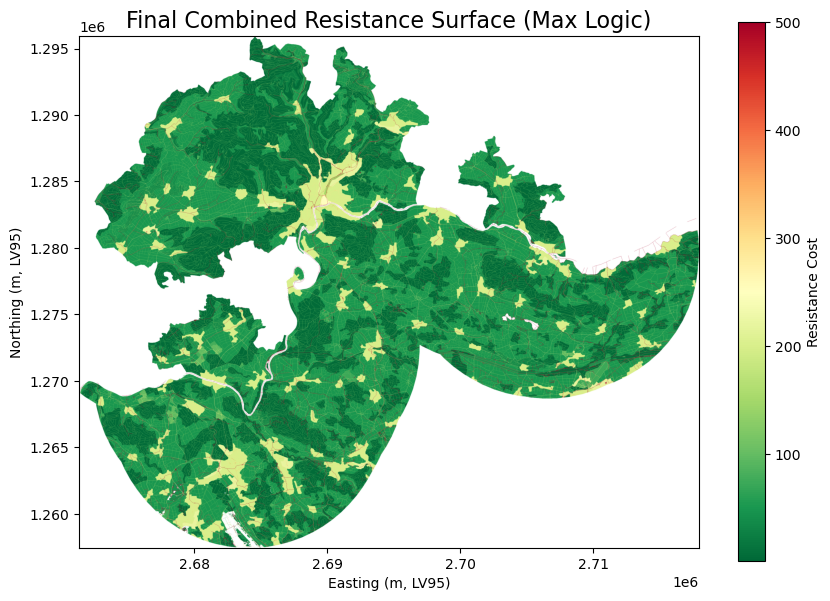


--- Workflow Complete ---


In [42]:
# --- 8. Visualize Final Result ---
print("Plotting final resistance surface...")
gu.plot_cost_surface(FINAL_RASTER, 'Final Combined Resistance Surface (Max Logic)', max_cost=500) # Adjust max_cost based on your highest barrier

print("\n--- Workflow Complete ---")